# Bayesian Probability Analysis — IMDb Movie Reviews
**Author:** Isimbi Selena  
**Assignment:** Formative 3 — Part 2 (Bayesian Probability)

This notebook implements **Bayes' Theorem in pure Python** (standard library only,
no external machine-learning libraries) to compute, for each chosen keyword, the
posterior probability that a review is *positive* given that the keyword appears in it:

$$P(\text{Positive}\mid \text{keyword}) = \frac{P(\text{keyword}\mid \text{Positive})\; P(\text{Positive})}{P(\text{keyword})}$$

All counts are read **live** from `IMDB_Dataset.csv` (50,000 reviews).

In [1]:
# Standard library only — no ML libraries (per assignment rules)
import csv
import re

DATASET_PATH = "IMDB_Dataset.csv"

# Keywords chosen as a group.
# Every count below is computed from the dataset, never hand-entered.
POSITIVE_KEYWORDS = ["masterpiece", "wonderful", "brilliant"]
NEGATIVE_KEYWORDS = ["boring", "disappointing", "waste of time"]
CONTROL_KEYWORDS  = ["funny"]          # appears in both classes -> sanity check

ALL_KEYWORDS = POSITIVE_KEYWORDS + NEGATIVE_KEYWORDS + CONTROL_KEYWORDS

print("Positive keywords:", POSITIVE_KEYWORDS)
print("Negative keywords:", NEGATIVE_KEYWORDS)
print("Control  keyword :", CONTROL_KEYWORDS)

Positive keywords: ['masterpiece', 'wonderful', 'brilliant']
Negative keywords: ['boring', 'disappointing', 'waste of time']
Control  keyword : ['funny']


In [2]:
def load_reviews(path):
    """Yield (lowercased_review_text, sentiment) for every row in the CSV."""
    with open(path, encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            yield row["review"].lower(), row["sentiment"].strip().lower()


def count_class_totals(path):
    """Return (total, positive, negative) review counts."""
    total = positive = negative = 0
    for _, sentiment in load_reviews(path):
        total += 1
        if sentiment == "positive":
            positive += 1
        elif sentiment == "negative":
            negative += 1
    return total, positive, negative


TOTAL, POSITIVE, NEGATIVE = count_class_totals(DATASET_PATH)

print("DATASET STATISTICS")
print("-" * 32)
print(f"Total reviews    : {TOTAL:,}")
print(f"Positive reviews : {POSITIVE:,} ({POSITIVE/TOTAL:.0%})")
print(f"Negative reviews : {NEGATIVE:,} ({NEGATIVE/TOTAL:.0%})")
print(f"Prior P(Positive): {POSITIVE/TOTAL:.4f}")

DATASET STATISTICS
--------------------------------
Total reviews    : 50,000
Positive reviews : 25,000 (50%)
Negative reviews : 25,000 (50%)
Prior P(Positive): 0.5000


In [3]:
def build_keyword_patterns(keywords):
    """Pre-compile a word-boundary regex for each keyword (DRY, reused below)."""
    return {kw: re.compile(r"\b" + re.escape(kw) + r"\b") for kw in keywords}


def count_keyword_occurrences(path, keywords):
    """Single pass over the data. For each keyword, count how many POSITIVE and
    how many NEGATIVE reviews contain it at least once.

    Returns: {keyword: {"pos": int, "neg": int}}
    """
    patterns = build_keyword_patterns(keywords)
    counts = {kw: {"pos": 0, "neg": 0} for kw in keywords}
    for text, sentiment in load_reviews(path):
        bucket = "pos" if sentiment == "positive" else "neg"
        for kw, pattern in patterns.items():
            if pattern.search(text):
                counts[kw][bucket] += 1
    return counts


KEYWORD_COUNTS = count_keyword_occurrences(DATASET_PATH, ALL_KEYWORDS)

print(f"{'keyword':<15}{'in +':>8}{'in -':>8}{'total':>8}")
print("-" * 39)
for kw in ALL_KEYWORDS:
    c = KEYWORD_COUNTS[kw]
    print(f"{kw:<15}{c['pos']:>8}{c['neg']:>8}{c['pos'] + c['neg']:>8}")

keyword            in +    in -   total
---------------------------------------
masterpiece         878     329    1207
wonderful          2258     522    2780
brilliant          1587     501    2088
boring              591    2460    3051
disappointing       171     615     786
waste of time        30     661     691
funny              3089    3286    6375


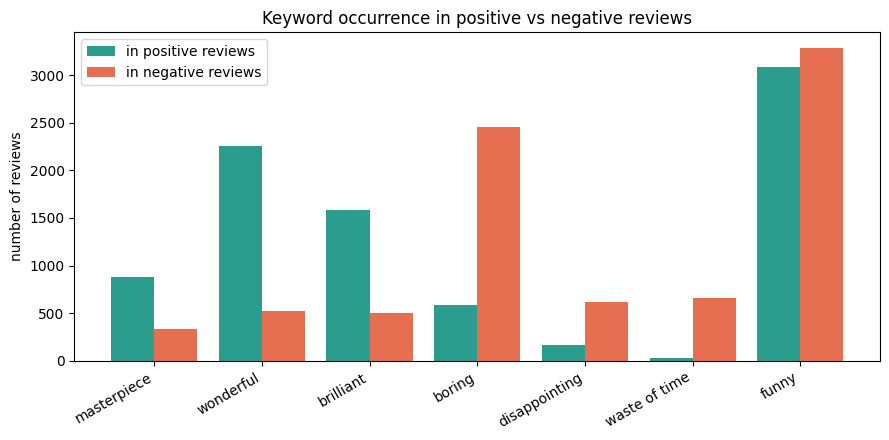

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt   # visualization only -- not used in the Bayes computation

kws = ALL_KEYWORDS
pos_counts = [KEYWORD_COUNTS[k]["pos"] for k in kws]
neg_counts = [KEYWORD_COUNTS[k]["neg"] for k in kws]
x = range(len(kws))
w = 0.4

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar([i - w/2 for i in x], pos_counts, width=w, label="in positive reviews", color="#2a9d8f")
ax.bar([i + w/2 for i in x], neg_counts, width=w, label="in negative reviews", color="#e76f51")
ax.set_xticks(list(x))
ax.set_xticklabels(kws, rotation=30, ha="right")
ax.set_ylabel("number of reviews")
ax.set_title("Keyword occurrence in positive vs negative reviews")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
def bayes_posterior(keyword_pos, keyword_neg, total, positive):
    """Apply Bayes' Theorem for one keyword.

    Returns the four required probabilities:
        prior      = P(Positive)
        likelihood = P(keyword | Positive)
        marginal   = P(keyword)
        posterior  = P(Positive | keyword)
    """
    keyword_total = keyword_pos + keyword_neg
    prior      = positive / total
    likelihood = keyword_pos / positive          # P(keyword | Positive)
    marginal   = keyword_total / total           # P(keyword)
    posterior  = (likelihood * prior) / marginal # Bayes' Theorem
    return {
        "prior": prior,
        "likelihood": likelihood,
        "marginal": marginal,
        "posterior": posterior,
        "keyword_total": keyword_total,
    }


def analyse(keywords):
    """Run Bayes for a list of keywords and return a list of result dicts."""
    results = []
    for kw in keywords:
        c = KEYWORD_COUNTS[kw]
        r = bayes_posterior(c["pos"], c["neg"], TOTAL, POSITIVE)
        r["keyword"] = kw
        results.append(r)
    return results


RESULTS = analyse(ALL_KEYWORDS)

In [6]:
print("BAYESIAN PROBABILITY TABLE")
print("=" * 78)
print(f"{'keyword':<15}{'P(Pos)':>9}{'P(kw|Pos)':>12}{'P(kw)':>10}{'P(Pos|kw)':>12}   label")
print("-" * 78)
for r in RESULTS:
    if r["keyword"] in CONTROL_KEYWORDS:
        label = "CONTROL"
    else:
        label = "POSITIVE" if r["posterior"] >= 0.5 else "NEGATIVE"
    print(f"{r['keyword']:<15}"
          f"{r['prior']:>9.4f}"
          f"{r['likelihood']:>12.5f}"
          f"{r['marginal']:>10.5f}"
          f"{r['posterior']:>12.3f}   {label}")
print("=" * 78)

BAYESIAN PROBABILITY TABLE
keyword           P(Pos)   P(kw|Pos)     P(kw)   P(Pos|kw)   label
------------------------------------------------------------------------------
masterpiece       0.5000     0.03512   0.02414       0.727   POSITIVE
wonderful         0.5000     0.09032   0.05560       0.812   POSITIVE
brilliant         0.5000     0.06348   0.04176       0.760   POSITIVE
boring            0.5000     0.02364   0.06102       0.194   NEGATIVE
disappointing     0.5000     0.00684   0.01572       0.218   NEGATIVE
waste of time     0.5000     0.00120   0.01382       0.043   NEGATIVE
funny             0.5000     0.12356   0.12750       0.485   CONTROL


In [7]:
print("WORKED CALCULATIONS (per keyword)")
print("=" * 60)
for r in RESULTS:
    print(f"\nP(Positive | \"{r['keyword']}\")")
    print(f"   P(keyword | Positive) = {r['likelihood']:.5f}")
    print(f"   P(Positive)           = {r['prior']:.4f}")
    print(f"   P(keyword)            = {r['marginal']:.5f}")
    print(f"   = ({r['likelihood']:.5f} x {r['prior']:.4f}) / {r['marginal']:.5f}")
    print(f"   = {r['posterior']:.3f}  ->  {r['posterior']:.1%} chance positive")

WORKED CALCULATIONS (per keyword)

P(Positive | "masterpiece")
   P(keyword | Positive) = 0.03512
   P(Positive)           = 0.5000
   P(keyword)            = 0.02414
   = (0.03512 x 0.5000) / 0.02414
   = 0.727  ->  72.7% chance positive

P(Positive | "wonderful")
   P(keyword | Positive) = 0.09032
   P(Positive)           = 0.5000
   P(keyword)            = 0.05560
   = (0.09032 x 0.5000) / 0.05560
   = 0.812  ->  81.2% chance positive

P(Positive | "brilliant")
   P(keyword | Positive) = 0.06348
   P(Positive)           = 0.5000
   P(keyword)            = 0.04176
   = (0.06348 x 0.5000) / 0.04176
   = 0.760  ->  76.0% chance positive

P(Positive | "boring")
   P(keyword | Positive) = 0.02364
   P(Positive)           = 0.5000
   P(keyword)            = 0.06102
   = (0.02364 x 0.5000) / 0.06102
   = 0.194  ->  19.4% chance positive

P(Positive | "disappointing")
   P(keyword | Positive) = 0.00684
   P(Positive)           = 0.5000
   P(keyword)            = 0.01572
   = (0.00684 x 0.50

In [8]:
positives = [r for r in RESULTS if r["keyword"] in POSITIVE_KEYWORDS]
negatives = [r for r in RESULTS if r["keyword"] in NEGATIVE_KEYWORDS]

best  = max(RESULTS, key=lambda r: r["posterior"])
worst = min(RESULTS, key=lambda r: r["posterior"])
control = next(r for r in RESULTS if r["keyword"] in CONTROL_KEYWORDS)

print("KEY FINDINGS")
print("-" * 50)
print(f"Prior baseline               : {POSITIVE/TOTAL:.0%}")
print(f"Strongest positive predictor : '{best['keyword']}' ({best['posterior']:.1%})")
print(f"Strongest negative predictor : '{worst['keyword']}' ({worst['posterior']:.1%})")
print(f"Control word 'funny'         : {control['posterior']:.1%} (near baseline, as expected)")
print()
print("All 3 positive keywords land above the 50% baseline;")
print("all 3 negative keywords land well below it. The control word")
print("'funny' sits close to 50%, confirming it carries little sentiment on its own.")

KEY FINDINGS
--------------------------------------------------
Prior baseline               : 50%
Strongest positive predictor : 'wonderful' (81.2%)
Strongest negative predictor : 'waste of time' (4.3%)
Control word 'funny'         : 48.5% (near baseline, as expected)

All 3 positive keywords land above the 50% baseline;
all 3 negative keywords land well below it. The control word
'funny' sits close to 50%, confirming it carries little sentiment on its own.


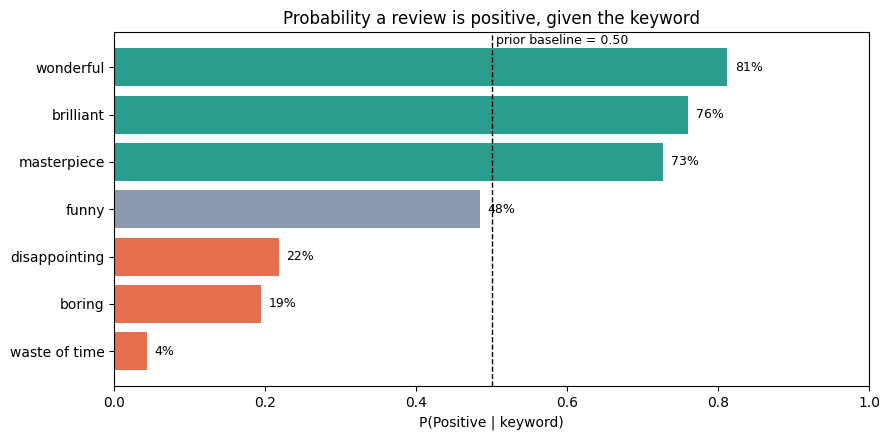

In [9]:
# Posterior P(Positive | keyword), sorted, with the 0.5 prior baseline
ordered = sorted(RESULTS, key=lambda r: r["posterior"])
names = [r["keyword"] for r in ordered]
posts = [r["posterior"] for r in ordered]

def bar_color(r):
    if r["keyword"] in CONTROL_KEYWORDS:
        return "#8d99ae"                       # grey  = control
    return "#2a9d8f" if r["posterior"] >= 0.5 else "#e76f51"  # green / red

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(names, posts, color=[bar_color(r) for r in ordered])
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.text(0.5, len(names) - 0.3, " prior baseline = 0.50", fontsize=9, va="top")
for i, p in enumerate(posts):
    ax.text(p + 0.01, i, f"{p:.0%}", va="center", fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel("P(Positive | keyword)")
ax.set_title("Probability a review is positive, given the keyword")
plt.tight_layout()
plt.show()

## Interpretation

- The three **positive** keywords all raise the probability of a positive review above the 50% prior, with *masterpiece*, *wonderful* and *brilliant* acting as reliable positive signals.
- The three **negative** keywords all push the probability well below 50%; *"waste of time"* is the single strongest negative signal in the set.
- The **control** word *funny* stays near the 50% baseline, which is exactly what we expect from a word that appears in praise ("funny and clever") and criticism ("tried to be funny and failed") alike. It is a useful sanity check that the method isn't simply labelling every common word as positive.

Bayes' Theorem lets us turn raw keyword counts into a defensible, quantitative statement about sentiment without any machine-learning library.